In [2]:
%pip install seaborn plotly

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached plotly-6.9.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached plotly-6.9.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)

   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwha


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: E:\Task2_Role Challenge\venv\Scripts\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

import plotly.express as px
import plotly.graph_objects as go

In [4]:
df = pd.read_csv(
    "../outputs/cleaned_retail.csv",
    parse_dates=["InvoiceDate"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,Quarter,Week,Day,DayName,Hour,Weekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,4,49,1,Tuesday,7,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,4,49,1,Tuesday,7,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,4,49,1,Tuesday,7,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,4,49,1,Tuesday,7,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,4,49,1,Tuesday,7,False


In [5]:
print(df.shape)

(779425, 18)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    779425 non-null  int64         
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   UnitPrice    779425 non-null  float64       
 6   CustomerID   779425 non-null  float64       
 7   Country      779425 non-null  str           
 8   TotalSales   779425 non-null  float64       
 9   Year         779425 non-null  int64         
 10  Month        779425 non-null  int64         
 11  MonthName    779425 non-null  str           
 12  Quarter      779425 non-null  int64         
 13  Week         779425 non-null  int64         
 14  Day          779425 non-null  int64         
 15  DayName      779425 non-null  str           


In [7]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalSales     0
Year           0
Month          0
MonthName      0
Quarter        0
Week           0
Day            0
DayName        0
Hour           0
Weekend        0
dtype: int64

In [8]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalSales,Year,Month,Quarter,Week,Day,Hour
count,779425.000000,779425.000000,779425,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000
mean,537426.828586,13.489370,2011-01-03 01:44:42.593476,3.218488,15320.360461,22.291823,2010.432051,7.417059,2.796884,30.126092,15.390961,12.791884
min,489434.000000,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000,2009.000000,1.000000,1.000000,1.000000,1.000000,6.000000
25%,514483.000000,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,4.950000,2010.000000,5.000000,2.000000,18.000000,8.000000,11.000000
50%,536754.000000,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,12.480000,2010.000000,8.000000,3.000000,33.000000,15.000000,13.000000
75%,561995.000000,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,19.800000,2011.000000,11.000000,4.000000,44.000000,23.000000,14.000000
max,581587.000000,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000,2011.000000,12.000000,4.000000,52.000000,31.000000,20.000000
std,26901.629627,145.855814,NaN,29.676140,1695.692775,227.427075,0.568385,3.422319,1.132107,14.840026,8.657939,2.294182


In [9]:
print("Total Revenue :", round(df["TotalSales"].sum(),2))

Total Revenue : 17374804.27


In [10]:
print(df["InvoiceNo"].nunique())

36969


In [11]:
print(df["CustomerID"].nunique())

5878


In [12]:
print(df["StockCode"].nunique())

4631


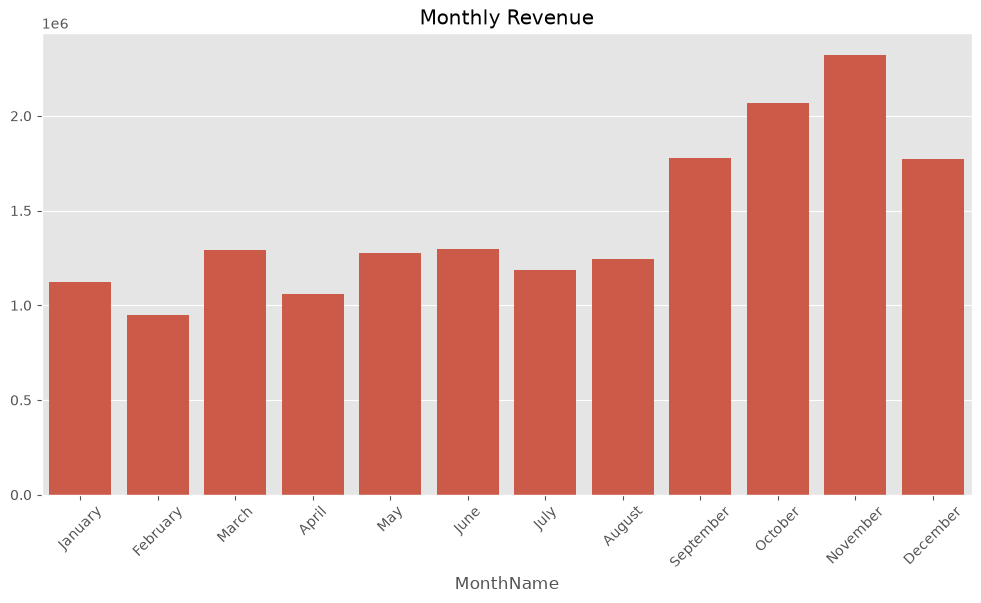

In [13]:
monthly_sales = df.groupby("MonthName")["TotalSales"].sum()

order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(order)

plt.figure(figsize=(12,6))

sns.barplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue")

plt.show()

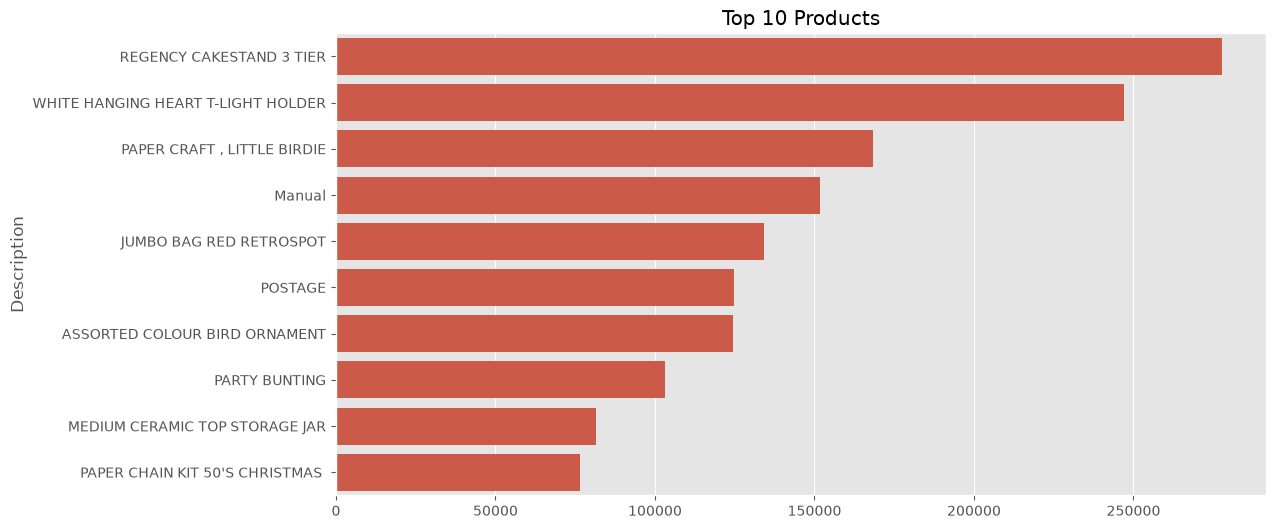

In [14]:
top_products = (
    df.groupby("Description")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products")

plt.show()

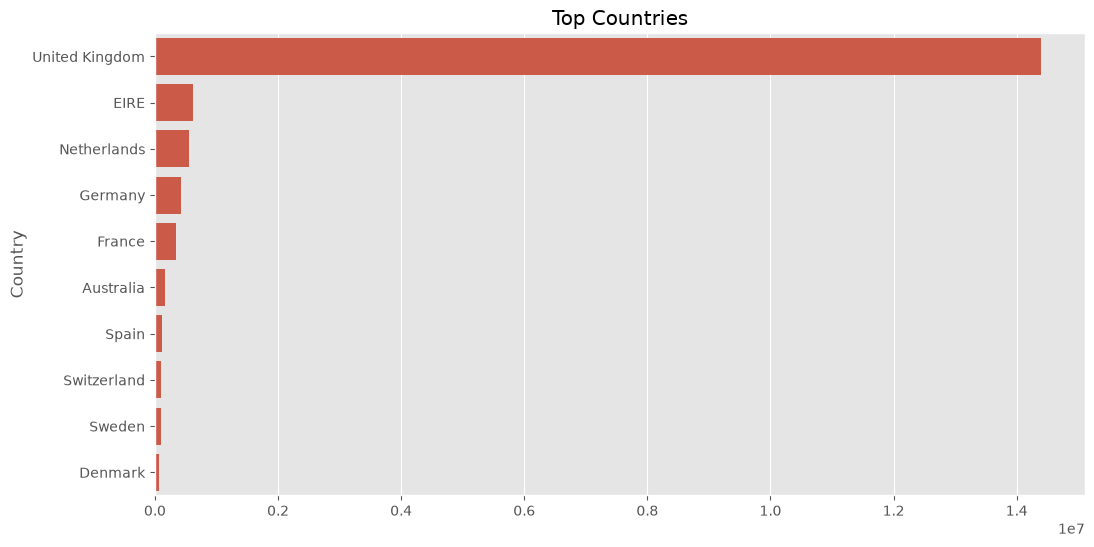

In [15]:
country_sales = (
    df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index
)

plt.title("Top Countries")

plt.show()

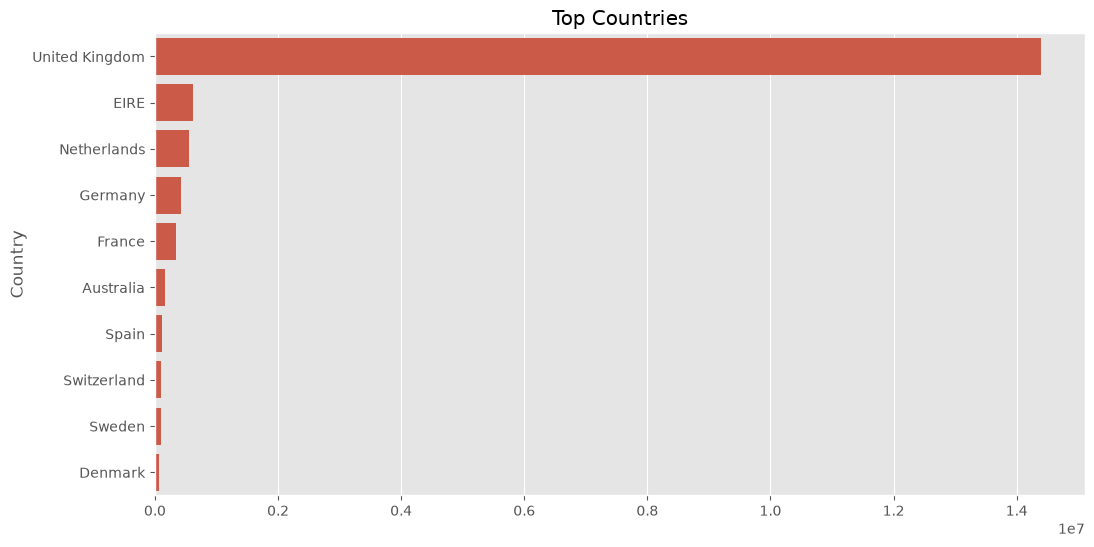

In [16]:
country_sales = (
    df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index
)

plt.title("Top Countries")

plt.show()

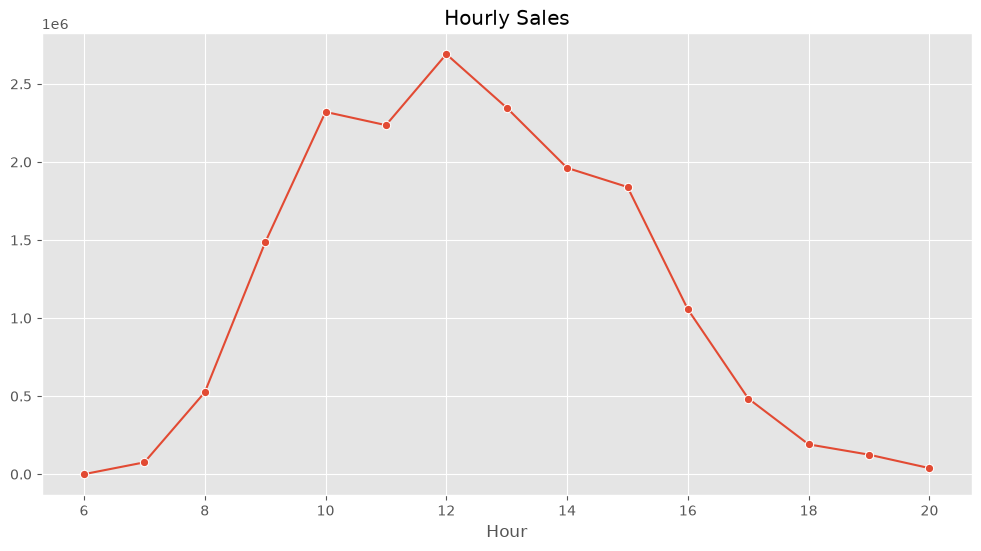

In [17]:
hourly = df.groupby("Hour")["TotalSales"].sum()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=hourly.index,
    y=hourly.values,
    marker="o"
)

plt.title("Hourly Sales")

plt.show()

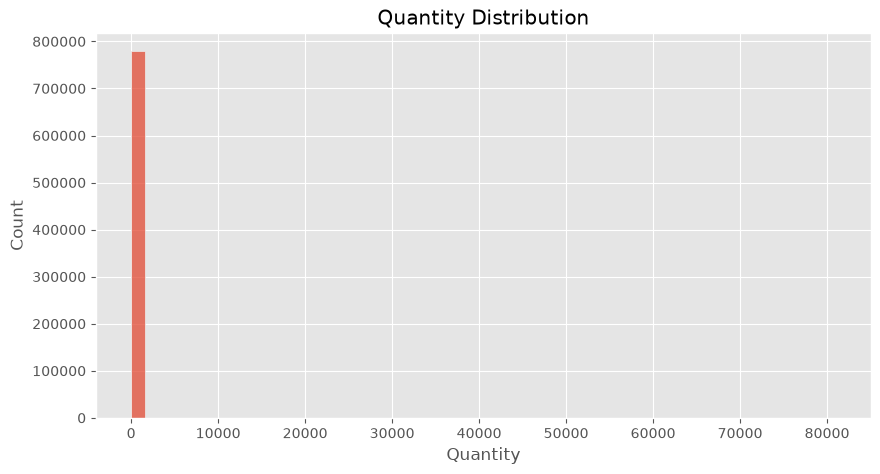

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Quantity"],
    bins=50
)

plt.title("Quantity Distribution")

plt.show()

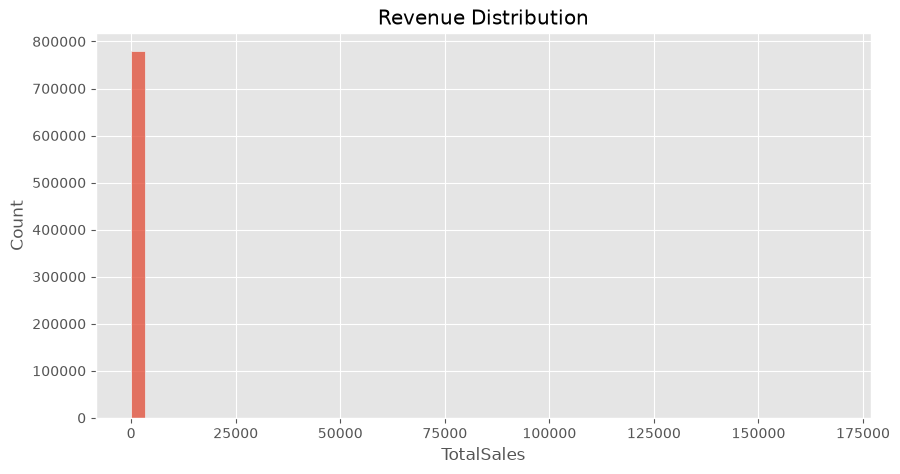

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["TotalSales"],
    bins=50
)

plt.title("Revenue Distribution")

plt.show()

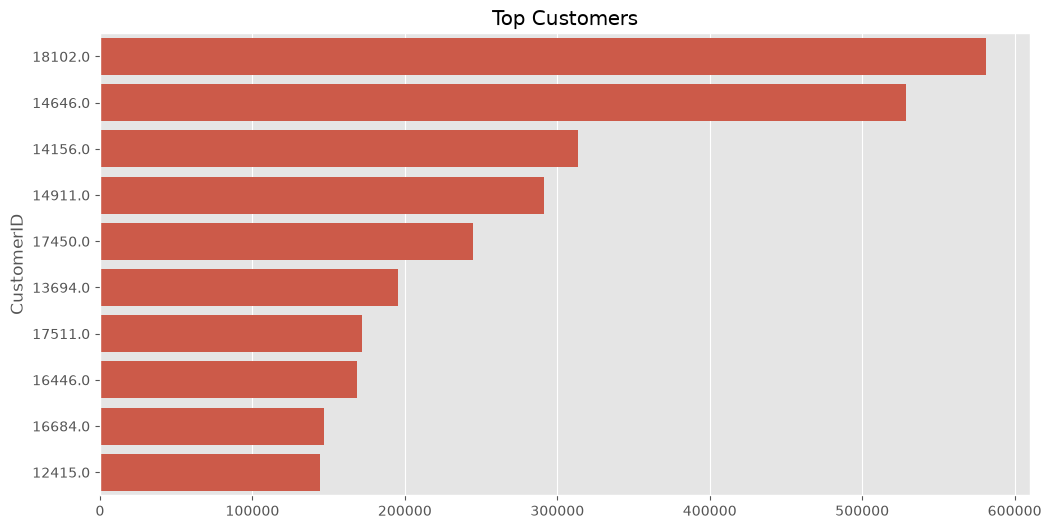

In [20]:
top_customers = (
    df.groupby("CustomerID")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str)
)

plt.title("Top Customers")

plt.show()

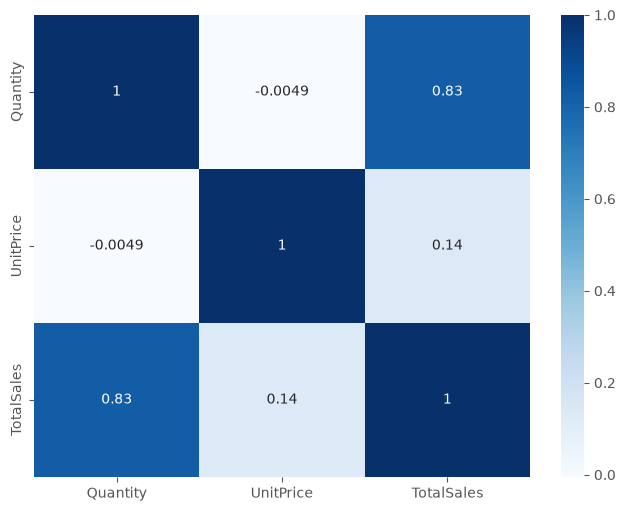

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[
        ["Quantity","UnitPrice","TotalSales"]
    ].corr(),
    annot=True,
    cmap="Blues"
)

plt.show()

In [22]:
df.to_csv("../outputs/final_retail_data.csv", index=False)

print("EDA Completed Successfully")

EDA Completed Successfully
